In [99]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [104]:
import os
import glob
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.model_selection import train_test_split


RANDOM_SEED = 1

## 1. Summurazition of the data files with a LLM

In [101]:
%pip install einops bitsandbytes accelerate
%pip install -U bitsandbytes


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [102]:
%pip show accelerate
%pip show bitsandbytes

Name: accelerate
Version: 1.4.0
Summary: Accelerate
Home-page: https://github.com/huggingface/accelerate
Author: The HuggingFace team
Author-email: zach.mueller@huggingface.co
License: Apache
Location: /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages
Requires: huggingface-hub, numpy, packaging, psutil, pyyaml, safetensors, torch
Required-by: peft
Note: you may need to restart the kernel to use updated packages.
Name: bitsandbytes
Version: 0.42.0
Summary: k-bit optimizers and matrix multiplication routines.
Home-page: https://github.com/TimDettmers/bitsandbytes
Author: Tim Dettmers
Author-email: dettmers@cs.washington.edu
License: MIT
Location: /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages
Requires: scipy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


### 1.1 Download the model

In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-32B-Instruct"
from transformers import BitsAndBytesConfig
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

# Load the model with the new quantization config
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    quantization_config=bnb_config
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

ImportError: Using `bitsandbytes` 4-bit quantization requires the latest version of bitsandbytes: `pip install -U bitsandbytes`

In [ ]:

def prepare_instruction(text):
    prompt = """Résume cet article en {nb_words} mots:\n{text}\n\Résulmé:"""
    return prompt.format(
        text=text,
        nb_words=100
    )

def summarization(text):
    instruction = prepare_instruction(text)
    input_ids = tokenizer(instruction, return_tensors="pt", truncation=True).input_ids.cuda()
    with torch.inference_mode():
      outputs = model.generate(
              input_ids=input_ids,
              max_new_tokens=128,
              do_sample=True,
              top_p=0.9,
              temperature=1e-2,
            )
      result = tokenizer.batch_decode(outputs.detach().cpu().numpy(), skip_special_tokens=True)[0]
      result = result[len(instruction) :]
      print(result)
      return result

text = """your text here to summarize"""
result = summarization(text)

model.safetensors.index.json:   0%|          | 0.00/63.2k [00:00<?, ?B/s]

model-00001-of-00017.safetensors:   0%|          | 0.00/3.92G [00:00<?, ?B/s]

KeyboardInterrupt: 

## 2. Load the data and get summary

In [ ]:
#tmp

summarize_text = lambda text: text[0:min(100, len(text))] + "..."

In [ ]:
def load_data(data_dir):
    data = []
    file_paths = glob.glob(os.path.join(data_dir, "*.txt"))
    for file in file_paths:
        with open(file, "r", encoding="utf-8") as f:
            text = f.read()
        summary = summarize_text(text)
        data.append((text, summary))
    return data

In [ ]:
data_dir = "./data/datasets/test/"
data = load_data(data_dir)

print("Number of samples:", len(data))

Number of samples: 31


In [ ]:
class SummarizationDataset(Dataset):
    def __init__(self, data):
        self.data = data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        orig, summ = self.data[idx]
        return orig, summ

## 3. Split dataset in train, test and validation

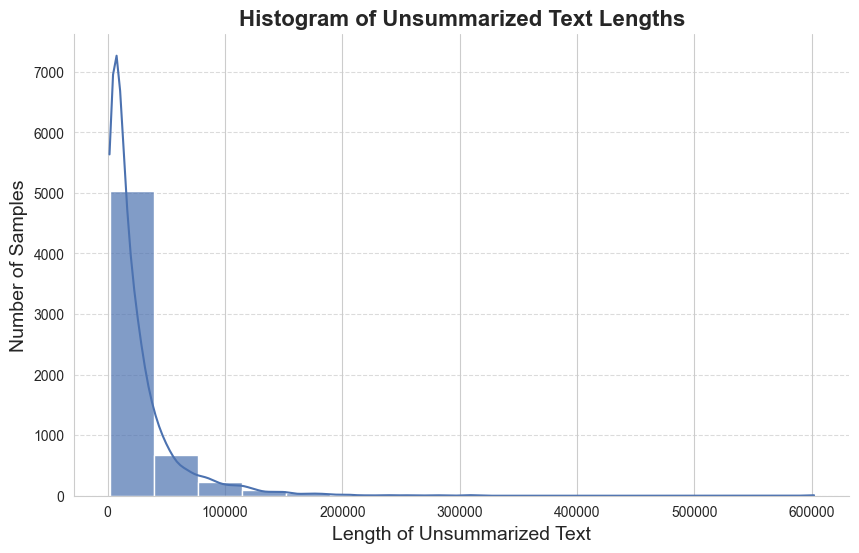

In [109]:

# --- Stratify the data based on unsummarized text length ---
# We compute the length of each unsummarized text and bin it into discrete bins.
lengths = np.array([len(x[0]) for x in data])
num_bins = min(max(len(data) // 100, 6), 16)  
bins = np.linspace(lengths.min(), lengths.max(), num_bins)
binned_lengths = np.digitize(lengths, bins)

# Ensure no bin has < 2 samples
unique, counts = np.unique(binned_lengths, return_counts=True)
valid_bins = {u for u, c in zip(unique, counts) if c >= 2*num_bins}

# Merge rare bins
for i in range(len(binned_lengths)):
    if binned_lengths[i] not in valid_bins:
        binned_lengths[i] = min(valid_bins, key=lambda x: abs(x - binned_lengths[i]))  # Merge to nearest


# plot histogram of lengths
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Plot histogram with KDE (kernel density estimate) for smoothness
sns.histplot(lengths, bins=num_bins, kde=True, color="#4C72B0", alpha=0.7)

plt.xlabel("Length of Unsummarized Text", fontsize=14)
plt.ylabel("Number of Samples", fontsize=14)
plt.title("Histogram of Unsummarized Text Lengths", fontsize=16, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.7)
sns.despine()
plt.show()


In [110]:

train_data, temp_data, train_strata, temp_strata = train_test_split(
    data, binned_lengths, test_size=0.4, random_state=RANDOM_SEED, stratify=binned_lengths
)

val_data, test_data, _, _ = train_test_split(
    temp_data, temp_strata, test_size=0.5, random_state=RANDOM_SEED, stratify=temp_strata
)

train_dataset = SummarizationDataset(train_data)
val_dataset   = SummarizationDataset(val_data)
test_dataset  = SummarizationDataset(test_data)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 3649
Validation size: 1217
Test size: 1217


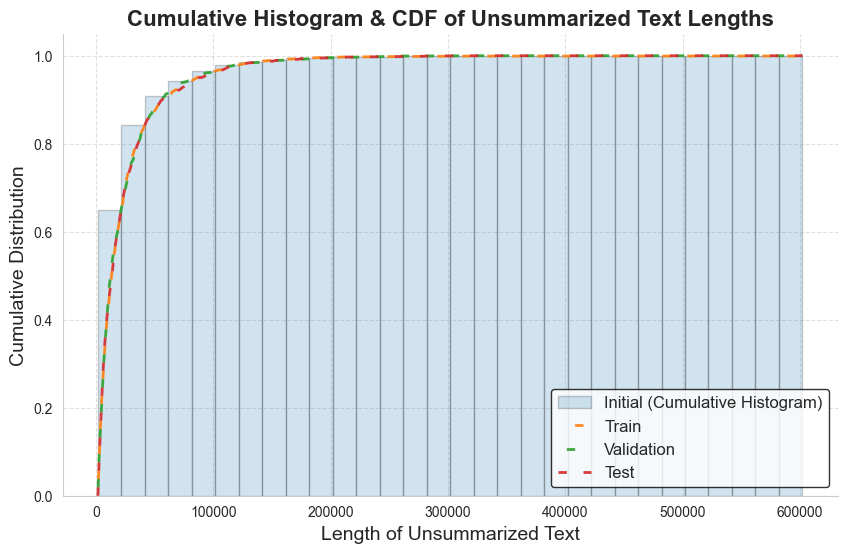

In [ ]:
train_lengths = np.array([len(x[0]) for x in train_data])
val_lengths = np.array([len(x[0]) for x in val_data])
test_lengths = np.array([len(x[0]) for x in test_data])
initial_lengths = np.array([len(x[0]) for x in data])

sorted_train = np.sort(train_lengths)
sorted_val = np.sort(val_lengths)
sorted_test = np.sort(test_lengths)

def compute_cdf(sorted_lengths, full_x_range):
    """Returns a CDF that extends to the full x-axis range."""
    cdf_values = np.linspace(0, 1, len(sorted_lengths))
    return np.interp(full_x_range, sorted_lengths, cdf_values, left=0, right=1)

x_range = np.linspace(min(initial_lengths), max(initial_lengths), 500)

train_cdf = compute_cdf(sorted_train, x_range)
val_cdf = compute_cdf(sorted_val, x_range)
test_cdf = compute_cdf(sorted_test, x_range)

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

colors = {
    "Initial": "#1f77b4",  # Blue
    "Train": "#ff7f0e",    # Orange
    "Validation": "#2ca02c",  # Green
    "Test": "#d62728"  # Red
}

# Cumulative histogram for Initial Distribution (Lower opacity & behind the lines)
plt.hist(
    initial_lengths, bins=30, cumulative=True, density=True, 
    color=colors["Initial"], alpha=0.2, label="Initial (Cumulative Histogram)", zorder=1
)

# Cumulative distribution lines with different dash patterns
train_line, = plt.plot(x_range, train_cdf, label="Train", color=colors["Train"], linewidth=2, alpha=0.9, zorder=2)
val_line, = plt.plot(x_range, val_cdf, label="Validation", color=colors["Validation"], linewidth=2, alpha=0.9, zorder=3)
test_line, = plt.plot(x_range, test_cdf, label="Test", color=colors["Test"], linewidth=2, alpha=0.9, zorder=4)

train_line.set_dashes([0, 6, 3, 0])
val_line.set_dashes([0, 3, 3, 3])
test_line.set_dashes([3, 6])

plt.xlabel("Length of Unsummarized Text", fontsize=14)
plt.ylabel("Cumulative Distribution", fontsize=14)
plt.title("Cumulative Histogram & CDF of Unsummarized Text Lengths", fontsize=16, fontweight="bold")

plt.legend(loc="lower right", fontsize=12, frameon=True, edgecolor="black")
plt.grid(True, linestyle="--", alpha=0.6)
sns.despine()
plt.show()
